# Digits: MLP с аугментацией сдвигами

Проверяем, помогает ли аугментация сдвигами на 1 пиксель (`ml_toolkit.features.augment_digits`) многослойному перцептрону на датасете digits (8x8).

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "png"
plt.rcParams["figure.dpi"] = 72
from sklearn.pipeline import make_pipeline
from ml_toolkit.data import make_split
from ml_toolkit.features import make_preprocessor, augment_digits
from ml_toolkit.models import build_model
from ml_toolkit.metrics import calc_metrics
from ml_toolkit.viz import plot_confusion

In [2]:
split = make_split("digits", seed=0)
split.sizes()

{'train': 1077, 'val': 360, 'test': 360}

## Гиперпараметры

Одинаковые для обоих вариантов, меняется только обучающая выборка.

In [3]:
HPARAMS = dict(hidden_layer_sizes=(128,), learning_rate_init=3e-3, alpha=1e-4,
               batch_size=64, max_iter=200, random_state=0)

In [4]:
base = make_pipeline(make_preprocessor(), build_model("mlp", **HPARAMS))
base.fit(split.X_train, split.y_train)
m_base = calc_metrics(split.y_val, base.predict(split.X_val), base.predict_proba(split.X_val))
print("no augmentation:", {k: round(v, 4) for k, v in m_base.items()})

no augmentation: {'accuracy': 0.9722, 'f1': 0.9722, 'roc_auc': 0.9983}


In [5]:
X_aug, y_aug = augment_digits(split.X_train, split.y_train)
print("train size:", len(split.y_train), "->", len(y_aug))
aug = make_pipeline(make_preprocessor(), build_model("mlp", **HPARAMS))
aug.fit(X_aug, y_aug)
m_aug = calc_metrics(split.y_val, aug.predict(split.X_val), aug.predict_proba(split.X_val))
print("with augmentation:", {k: round(v, 4) for k, v in m_aug.items()})

train size: 1077 -> 5385


with augmentation: {'accuracy': 0.9778, 'f1': 0.9781, 'roc_auc': 0.9998}


In [6]:
pd.DataFrame({"no_aug": m_base, "shift_aug": m_aug}).T.round(4)

,accuracy,f1,roc_auc
no_aug,0.9722,0.9722,0.9983
shift_aug,0.9778,0.9781,0.9998


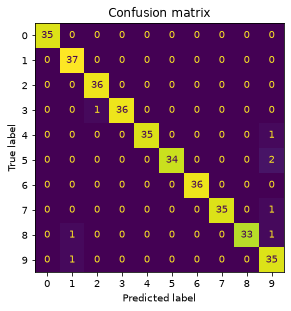

In [7]:
plot_confusion(split.y_val, aug.predict(split.X_val))
plt.show()

Итог по аугментации — в таблице выше. Матрица ошибок показывает, какие цифры путаются чаще всего.